# Preprocesamiento de Datos

## A. Carga del conjunto de datos
El dataset fue obtenido mediante el uso de la API sodapy del portal de Datos Abiertos de Colombia. Este enfoque garantiza que los datos estén siempre actualizados y con formato estándar.

In [337]:
!pip install sodapy
from sodapy import Socrata
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Conexión a la API de datos.gov.co
client = Socrata("www.datos.gov.co", None)
results = client.get("e97j-vuf7", limit=360000)

# Conversión a DataFrame
df = pd.DataFrame.from_records(results)

In [338]:
# Dump df original a archivos
# df.to_csv("colombianos_detenidos_raw.csv", index=False, encoding='utf-8')
# df.to_csv("colombianos_detenidos_raw_excel.csv", index=False, encoding='utf-8-sig')

## B. Conversión de tipos y transformación inicial
Se identificaron columnas numéricas y de fecha que originalmente eran tratadas como cadenas de texto (object). Se aplicó conversión explícita para asegurar su correcto uso.

In [271]:
# Conversión de tipos
df["cantidad"] = pd.to_numeric(df["cantidad"], errors='coerce')
df["fecha_publicaci_n"] = pd.to_datetime(df["fecha_publicaci_n"], errors='coerce') # Corrected column name

## C. Eliminación de duplicados

Primero, validar si existen registros duplicados en el set de datos:

In [272]:
df_clean = df.copy()

# Conversión de columnas que pueden presentar errores al utilizar la función de encontrar duplicados
for col in df.columns:
    if df[col].apply(lambda x: isinstance(x, (dict, list))).any():
        df_clean[col] = df[col].apply(str)

# Ahora se pueden validar la cantidad de duplicados
registros_duplicados = df_clean.duplicated().sum()
print(f'Cantidad de registros duplicados: {registros_duplicados}')
print(f'Porcentaje de registros duplicados: {registros_duplicados*100/len(df)}%')

Cantidad de registros duplicados: 32596
Porcentaje de registros duplicados: 9.054444444444444%


Teniendo así que un 9% de los registros del dataset son registros duplicados. Por lo cual no presentará un impacto tan grande el eliminarlos:

In [273]:
df_sin_dups = df_clean.drop_duplicates()
print(f'Tamaño dataset original: {len(df)}')
print(f'Tamaño dataset sin duplicados: {len(df_sin_dups)}')

Tamaño dataset original: 360000
Tamaño dataset sin duplicados: 327404


Con lo anterior podemos ver que los registros duplicados fueron removidos éxitosamente.

## D. Tratamiento de errores de codificación

A lo largo del dataset, como fue evidenciado en el análisis, varias columnas presentan valores que incluyen el caracter '�', el cual es un error de codificación que puede hacer de palabras como 'Narcotráfico' o países como 'España' aparcer como dos valores distintos ante los algoritmos que se apliquen al dataset, por lo cual primero es importante encontrarlos y reemplazarlos:

In [274]:
counts = df_sin_dups.apply(lambda col: col.astype(str).str.contains('�').sum())
print(counts)

fecha_publicaci_n                 0
pais_prisi_n                   5101
consulado                       551
delito                        61640
extraditado_y_o_repatriado        0
situaci_n_jur_dica            82773
g_nero                            0
grupo_edad                        0
geocoded_column                   0
cantidad                          0
latitud                           0
longitud                          0
dtype: int64


Viendo así que se debe enfocar el tratamiento en los atributos pais_prisi_n, consulado, delito y situaci_n_jur_dica

### Atributo país prisión

In [275]:
valores_pais = df_sin_dups[df_sin_dups['pais_prisi_n'].astype(str).str.contains('�')]['pais_prisi_n']
valores_pais.value_counts()

,count
pais_prisi_n,
ESPA�A,4925
CURA�AO,176


Para esta primera columna vemos que sólo dos valores distintos se ven perjudicados: España Y Curaçao. Con un valor bajo de ocurrencias.

In [276]:
df_sin_dups_bien_codif = df_sin_dups.copy()
df_sin_dups_bien_codif['pais_prisi_n'] = df_sin_dups_bien_codif['pais_prisi_n'].replace('ESPA�A', 'ESPAÑA')
df_sin_dups_bien_codif['pais_prisi_n'] = df_sin_dups_bien_codif['pais_prisi_n'].replace('CURA�AO', 'CURAÇAO')

Una vez reemplazados, hay que ver el antes:

In [277]:
df_sin_dups[df_sin_dups['pais_prisi_n'].isin(['ESPAÑA', 'CURAÇAO'])]['pais_prisi_n'].value_counts()

,count
pais_prisi_n,
ESPAÑA,13696
CURAÇAO,454


Y el después:

In [278]:
df_sin_dups_bien_codif[df_sin_dups_bien_codif['pais_prisi_n'].isin(['ESPAÑA', 'CURAÇAO'])]['pais_prisi_n'].value_counts()

,count
pais_prisi_n,
ESPAÑA,18621
CURAÇAO,630


In [279]:
df_sin_dups_bien_codif['pais_prisi_n'].astype(str).str.contains('�').sum()

np.int64(0)

Evidenciando así que los valores fueron corregidos éxitosamente

### Atributo consulado

In [280]:
valores_consulado = df_sin_dups[df_sin_dups['consulado'].astype(str).str.contains('�')]['consulado']
valores_consulado.value_counts()

,count
consulado,
C. PUERTO ESPA�A,551


En el caso de los consulados, sólo se presenta un valor afectado.

In [281]:
df_sin_dups_bien_codif['consulado'] = df_sin_dups_bien_codif['consulado'].replace('C. PUERTO ESPA�A', 'C. PUERTO ESPAÑA')

Antes:

In [282]:
df_sin_dups[df_sin_dups['consulado'] == 'C. PUERTO ESPAÑA']['consulado'].value_counts()

,count
consulado,
C. PUERTO ESPAÑA,302


Después:

In [283]:
df_sin_dups_bien_codif[df_sin_dups_bien_codif['consulado'] == 'C. PUERTO ESPAÑA']['consulado'].value_counts()

,count
consulado,
C. PUERTO ESPAÑA,853


In [284]:
df_sin_dups_bien_codif['consulado'].astype(str).str.contains('�').sum()

np.int64(0)

### Atributo delito

In [285]:
valores_delito = df_sin_dups[df_sin_dups['delito'].astype(str).str.contains('�')]['delito']
valores_delito.value_counts()

,count
delito,
NARCOTR�FICO,47890
NO REPORTA � CONFIDENCIALIDAD ESTATAL,6338
EXTORSI�N,3341
CONDUCCI�N TEMERARIA,1221
DA�OS,1160
FALSIFICACI�N,1036
DELITOS POL�TICOS,303
COACCI�N,269
CELEBRACI�N INDEBIDA DE CONTRATOS,82


En el caso de los delitos, del contexto se puede deducir el reemplazo de estos símbolos en todos los valores menos en el de no reporta, por lo cual es prudente ver si hay otro valor igual pero sin el error de codificación

In [286]:
df_sin_dups[df_sin_dups['delito'].astype(str).str.contains('NO REPORTA')]['delito']

,delito
8,NO REPORTA – CONFIDENCIALIDAD ESTATAL
30,NO REPORTA – CONFIDENCIALIDAD ESTATAL
95,NO REPORTA – CONFIDENCIALIDAD ESTATAL
178,NO REPORTA – CONFIDENCIALIDAD ESTATAL
250,NO REPORTA – CONFIDENCIALIDAD ESTATAL
...,...
359888,NO REPORTA � CONFIDENCIALIDAD ESTATAL
359926,NO REPORTA � CONFIDENCIALIDAD ESTATAL
359940,NO REPORTA � CONFIDENCIALIDAD ESTATAL
359958,NO REPORTA � CONFIDENCIALIDAD ESTATAL


Viendo así que en este caso particular, este símbolo debe ser reemplazado por un guión.

In [287]:
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('NARCOTR�FICO', 'NARCOTRÁFICO')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('NO REPORTA � CONFIDENCIALIDAD ESTATAL', 'NO REPORTA – CONFIDENCIALIDAD ESTATAL')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('EXTORSI�N', 'EXTORSIÓN')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('CONDUCCI�N TEMERARIA', 'CONDUCCIÓN TEMERARIA')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('DA�OS', 'DAÑOS')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('FALSIFICACI�N', 'FALSIFICACIÓN')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('DELITOS POL�TICOS', 'DELITOS POLÍTICOS')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('COACCI�N', 'COACCIÓN')
df_sin_dups_bien_codif['delito'] = df_sin_dups_bien_codif['delito'].replace('CELEBRACI�N INDEBIDA DE CONTRATOS', 'CELEBRACIÓN INDEBIDA DE CONTRATOS')

Antes:

In [288]:
delitos_bien_codif = ['NARCOTRÁFICO', 'NO REPORTA – CONFIDENCIALIDAD ESTATAL', 'EXTORSIÓN', 'CONDUCCIÓN TEMERARIA', 'DAÑOS', 'FALSIFICACIÓN', 'DELITOS POLÍTICOS', 'COACCIÓN', 'CELEBRACIÓN INDEBIDA DE CONTRATOS']

df_sin_dups[df_sin_dups['delito'].isin(delitos_bien_codif)]['delito'].value_counts()

,count
delito,
NARCOTRÁFICO,29439
NO REPORTA – CONFIDENCIALIDAD ESTATAL,3843
EXTORSIÓN,1894
CONDUCCIÓN TEMERARIA,764
FALSIFICACIÓN,640
DAÑOS,536
COACCIÓN,203
DELITOS POLÍTICOS,93
CELEBRACIÓN INDEBIDA DE CONTRATOS,65


Después:

In [289]:
df_sin_dups_bien_codif[df_sin_dups_bien_codif['delito'].isin(delitos_bien_codif)]['delito'].value_counts()

,count
delito,
NARCOTRÁFICO,77329
NO REPORTA – CONFIDENCIALIDAD ESTATAL,10181
EXTORSIÓN,5235
CONDUCCIÓN TEMERARIA,1985
DAÑOS,1696
FALSIFICACIÓN,1676
COACCIÓN,472
DELITOS POLÍTICOS,396
CELEBRACIÓN INDEBIDA DE CONTRATOS,147


In [290]:
df_sin_dups_bien_codif['delito'].astype(str).str.contains('�').sum()

np.int64(0)

### Atributo situación jurídica

In [291]:
valores_situacion_jur = df_sin_dups[df_sin_dups['situaci_n_jur_dica'].astype(str).str.contains('�')]['situaci_n_jur_dica']
valores_situacion_jur.value_counts()

,count
situaci_n_jur_dica,
EN INVESTIGACI�N,74826
EN ESPERA DE DEPORTACI�N,7947


Teniendo en este caso sólo dos valores a reemplazar:

In [292]:
df_sin_dups_bien_codif['situaci_n_jur_dica'] = df_sin_dups_bien_codif['situaci_n_jur_dica'].replace('EN INVESTIGACI�N', 'EN INVESTIGACIÓN')
df_sin_dups_bien_codif['situaci_n_jur_dica'] = df_sin_dups_bien_codif['situaci_n_jur_dica'].replace('EN ESPERA DE DEPORTACI�N', 'EN ESPERA DE DEPORTACIÓN')

Antes:

In [293]:
situaciones_bien_codif = ['EN INVESTIGACIÓN', 'EN ESPERA DE DEPORTACIÓN']
df_sin_dups[df_sin_dups['situaci_n_jur_dica'].isin(situaciones_bien_codif)]['situaci_n_jur_dica'].value_counts()

,count
situaci_n_jur_dica,
EN INVESTIGACIÓN,44378
EN ESPERA DE DEPORTACIÓN,4047


Después:

In [294]:
df_sin_dups_bien_codif[df_sin_dups_bien_codif['situaci_n_jur_dica'].isin(situaciones_bien_codif)]['situaci_n_jur_dica'].value_counts()

,count
situaci_n_jur_dica,
EN INVESTIGACIÓN,119204
EN ESPERA DE DEPORTACIÓN,11994


In [295]:
df_sin_dups_bien_codif['situaci_n_jur_dica'].astype(str).str.contains('�').sum()

np.int64(0)

### Validación final

In [296]:
counts = df_sin_dups_bien_codif.apply(lambda col: col.astype(str).str.contains('�').sum())
print(counts)

fecha_publicaci_n             0
pais_prisi_n                  0
consulado                     0
delito                        0
extraditado_y_o_repatriado    0
situaci_n_jur_dica            0
g_nero                        0
grupo_edad                    0
geocoded_column               0
cantidad                      0
latitud                       0
longitud                      0
dtype: int64


## E. Reducción atributos reduntantes

Ya que el atributo de geocoded_column tiene datos con el formato {'latitude': lat, 'longitude': lon}, pero con menos información, como se evidencia en el dataset original:

In [297]:
df.isnull().sum()

,0
fecha_publicaci_n,0
pais_prisi_n,0
consulado,0
delito,0
extraditado_y_o_repatriado,0
situaci_n_jur_dica,0
g_nero,0
grupo_edad,0
geocoded_column,238173
cantidad,0


Donde se puede observar cómo el atributo geocoded_column presenta más datos faltantes que las columnas de latitud y longitud por separado, decidiendo así eliminar este atributo

In [298]:
df_sin_dups_bien_codif.drop(columns=["geocoded_column"], inplace=True)

## F. Tratamiento de valores faltantes (Parte 1)

### Datos nulos

Los valores nulos que las librerías detectan son los siguientes:

In [299]:
df_sin_dups_bien_codif.isnull().sum()

,0
fecha_publicaci_n,0
pais_prisi_n,0
consulado,0
delito,0
extraditado_y_o_repatriado,0
situaci_n_jur_dica,0
g_nero,0
grupo_edad,0
cantidad,0
latitud,43373


En un primer momento, se observa que latitud y longitud presentan una cantidad considerable de datos faltantes. Para esto en un primer momento es ideal validar si un mismo par de coordenadas latitud longitud son asignadas a un mismo consulado:

In [300]:
# Crear una columna combinada de coordenadas
prueba_coordenadas = df_sin_dups_bien_codif.copy()
prueba_coordenadas['coordenadas'] = list(zip(prueba_coordenadas['latitud'], prueba_coordenadas['longitud']))

# Contar cuántos pares únicos de coordenadas hay por consulado
conteo_coords = prueba_coordenadas.groupby('consulado')['coordenadas'].nunique().reset_index()
conteo_coords.columns = ['consulado', 'conteo_coordenadas']

# Mostrar las coordenadas únicas por consulado
coords_unicas = prueba_coordenadas.groupby('consulado')['coordenadas'].unique().reset_index()

# Puedes unir esto al conteo
df_resultado = conteo_coords.merge(coords_unicas, on='consulado')

print(df_resultado)

           consulado  conteo_coordenadas  \
0    BTA. ASISTENCIA                  16   
1       C. ABU DHABI                   4   
2            C. ACRA                   7   
3       C. AMSTERDAM                   3   
4          C. ANKARA                   4   
..               ...                 ...   
115         C. VIENA                   7   
116    C. WASHINGTON                   3   
117    C. WILLEMSTAD                   4   
118      DESCONOCIDA                   3   
119     SC. TEL AVIV                   3   

                                           coordenadas  
0    [(0, 0), (37.09024, -95.712891), (8.537981, -8...  
1    [(23.424076, 53.847818), (25.354826, 51.183884...  
2    [(8.619543, 0.824782), (7.946527, -1.023194), ...  
3          [(52.132633, 5.291266), (0, 0), (nan, nan)]  
4    [(38.963745, 35.243322), (0, 0), (42.315407, 4...  
..                                                 ...  
115  [(49.817492, 15.472962), (47.516231, 14.550072...  
116       [(37.

Se puede observar cómo a un mismo consulado le pueden ser asignadas en el dataset distintas coordenadas. Por lo cual, será prudente utilizar las coordenadas que más se asocian al consulado para así llenar los valores faltantes de estos atributos

In [301]:
# Obtener el par más frecuente por consulado
coord_mas_comunes = (
    prueba_coordenadas.dropna(subset=['latitud', 'longitud'])  # asegurarse de no contar nulos
      .groupby('consulado')['coordenadas']
      .agg(lambda x: x.value_counts().idxmax())
      .reset_index()
)

# Renombrar columnas
coord_mas_comunes[['latitud_mas_comun', 'longitud_mas_comun']] = pd.DataFrame(coord_mas_comunes['coordenadas'].tolist(), index=coord_mas_comunes.index)

# Eliminar la columna de tuplas para claridad
coord_mas_comunes = coord_mas_comunes.drop(columns='coordenadas')

# Hacer merge del dataset
merged_df = prueba_coordenadas.merge(coord_mas_comunes, on='consulado', how='left')
# Rellenar los valores
merged_df['latitud'] = merged_df['latitud'].fillna(merged_df['latitud_mas_comun'])
merged_df['longitud'] = merged_df['longitud'].fillna(merged_df['longitud_mas_comun'])
# Eliminar columnas que ya no son necesarias
merged_df = merged_df.drop(columns=['latitud_mas_comun', 'longitud_mas_comun', 'coordenadas'])

Ahora, validando si en el dataset temporal ya no hay nulos:

In [302]:
merged_df.isnull().sum()

,0
fecha_publicaci_n,0
pais_prisi_n,0
consulado,0
delito,0
extraditado_y_o_repatriado,0
situaci_n_jur_dica,0
g_nero,0
grupo_edad,0
cantidad,0
latitud,26


La cantidad de nulos se redujo considerablemente. Para finalizar, se tomará una estrategia ya presente en el dataset: utilizar 0,0 (el cual es un punto en el mar) para valores desconocidos de las coordenadas:

In [303]:
merged_df['latitud'] = merged_df['latitud'].fillna(0)
merged_df['longitud'] = merged_df['longitud'].fillna(0)

Validando:

In [304]:
merged_df.isnull().sum()

,0
fecha_publicaci_n,0
pais_prisi_n,0
consulado,0
delito,0
extraditado_y_o_repatriado,0
situaci_n_jur_dica,0
g_nero,0
grupo_edad,0
cantidad,0
latitud,0


Asignando a nuevo dataset:

In [305]:
df_llenado_v1 = merged_df.copy()

### Datos no registrados diferentes de nulo

Es importante en un primer momento visualizar los distintos valores que pueden tomar los diferentes atributos, para así identificar datos faltantes que no son necesariamente 'nulos' que es lo que las librerías normalmente detectan:

In [306]:
for col in df_llenado_v1.columns:
  uniques = df_llenado_v1[col].unique()
  print(f"\nColumna: {col} ({len(uniques)} valores únicos)")
  print(uniques)


Columna: fecha_publicaci_n (60 valores únicos)
<DatetimeArray>
['2018-09-17 00:00:00', '2019-01-01 00:00:00', '2020-10-01 00:00:00',
 '2021-08-01 00:00:00', '2021-09-01 00:00:00', '2022-01-24 00:00:00',
 '2019-07-04 00:00:00', '2022-09-01 00:00:00', '2019-09-11 00:00:00',
 '2020-01-13 00:00:00', '2020-03-01 00:00:00', '2020-04-17 00:00:00',
 '2020-05-01 00:00:00', '2020-06-01 00:00:00', '2020-07-01 00:00:00',
 '2020-08-01 00:00:00', '2020-09-01 00:00:00', '2020-11-01 00:00:00',
 '2020-12-01 00:00:00', '2021-01-01 00:00:00', '2021-02-01 00:00:00',
 '2021-03-01 00:00:00', '2021-04-01 00:00:00', '2021-05-01 00:00:00',
 '2021-06-01 00:00:00', '2023-03-01 00:00:00', '2022-03-01 00:00:00',
 '2022-04-01 00:00:00', '2022-11-01 00:00:00', '2022-12-05 00:00:00',
 '2022-05-01 00:00:00', '2023-04-01 00:00:00', '2023-05-01 00:00:00',
 '2023-10-01 00:00:00', '2022-07-01 00:00:00', '2023-11-01 00:00:00',
 '2023-12-01 00:00:00', '2024-01-01 00:00:00', '2024-02-01 00:00:00',
 '2022-10-01 00:00:00', '2

Con esto, podemos ver cómo en la mayoría de atributos, el dato faltante está registrado como 'DESCONOCIDO' y en consulado como 'DESCONOCIDA'. Así pues, habrá que ver el conteo de estos:

In [307]:
counts_desconocido = df_llenado_v1.apply(lambda col: (col.astype(str).isin(['DESCONOCIDO', 'DESCONOCIDA'])).sum())
print(counts_desconocido)

fecha_publicaci_n                  0
pais_prisi_n                  191491
consulado                        606
delito                         32951
extraditado_y_o_repatriado    308357
situaci_n_jur_dica                 0
g_nero                           230
grupo_edad                     97078
cantidad                           0
latitud                            0
longitud                           0
dtype: int64


Cabe aclarar que no todos estos valores necesariamente necesitan un tratamiento, ya que el atributo país prisión tiene la significancia de ser un país donde se llevará el o los casos: siendo entonces algo lógico que si el/los casos aún no han sido condenados, entonces no se conoce la prisión en la cual se llevará a los individuos. Así mismo, habrán casos menores como hurtos en los cuales la sentencia no conlleve a prisión.

Algo similar pasa en el atributo extraditado y/o repatriado; los valores que puede tomar esta columna son: 'EXTRADITADO', 'REPATRIADO', 'EXTRADITADO, REPATRIADO' y 'DESCONOCIDO', por lo cual, el valor desconocido también puede representar el caso en el que no se ha extraditado ni repatriado ya que no hay ningún valor que represente el 'ninguno'.

<br>

Por lo cual, el valor 'DESCONOCIDO' no se considerará un valor faltante en los atributos de país prisión y en extraditado y/o repatriado, ya que el análisis sería más complicado y podría presentar sesgos que influyan en la calidad de los datos, siendo considerado un dato faltante sólo para los atributos de delito, género y grupo de edad, teniendo estos los siguientes porcentajes.

In [308]:
lon_dataset = len(df_llenado_v1)
conteo_consulado = (df_llenado_v1['consulado'].astype(str) == 'DESCONOCIDA').sum()
conteo_delito = (df_llenado_v1['delito'].astype(str) == 'DESCONOCIDO').sum()
conteo_genero = (df_llenado_v1['g_nero'].astype(str) == 'DESCONOCIDO').sum()
conteo_grupo_edad = (df_llenado_v1['grupo_edad'].astype(str) == 'DESCONOCIDO').sum()
print(f'Porcentaje desconocido consulado: {conteo_consulado*100/lon_dataset}%')
print(f'Porcentaje desconocido delito: {conteo_delito*100/lon_dataset}%')
print(f'Porcentaje desconocido género: {conteo_genero*100/lon_dataset}%')
print(f'Porcentaje desconocido grupo edad: {conteo_grupo_edad*100/lon_dataset}%')

Porcentaje desconocido consulado: 0.18509242403880222%
Porcentaje desconocido delito: 10.064324198849128%
Porcentaje desconocido género: 0.07024959988271372%
Porcentaje desconocido grupo edad: 29.650828945278615%


En base a lo anterior, se puede observar que género y consulado son atributos en los cuales se pueden ignorar estos datos faltantes:

In [309]:
# Reemplazar 'DESCONOCIDO' por NaN
df_llenado_v1['consulado'] = df_llenado_v1['consulado'].replace('DESCONOCIDA', np.nan)
df_llenado_v1['g_nero'] = df_llenado_v1['g_nero'].replace('DESCONOCIDO', np.nan)

df_llenado_v1 = df_llenado_v1.dropna(subset=['consulado', 'g_nero'])

Validando:

In [310]:
counts_desconocido = df_llenado_v1.apply(lambda col: (col.astype(str).isin(['DESCONOCIDO', 'DESCONOCIDA'])).sum())
print(counts_desconocido)

fecha_publicaci_n                  0
pais_prisi_n                  190792
consulado                          0
delito                         32228
extraditado_y_o_repatriado    307751
situaci_n_jur_dica                 0
g_nero                             0
grupo_edad                     97018
cantidad                           0
latitud                            0
longitud                           0
dtype: int64


Por otra parte, los atributos de delito y grupo edad presentan un porcentaje importante de datos faltantes, teniendo así que recurrir a métodos de rellenado. Sin embargo, dado los desbalances vistos en las siguientes gráficas, se plantea primero reducir el número de valores del atributo delito. Luego, en base a estos resultados determinar la forma de tratar con los valores faltantes de ambos atributos.

<Axes: xlabel='count', ylabel='grupo_edad'>

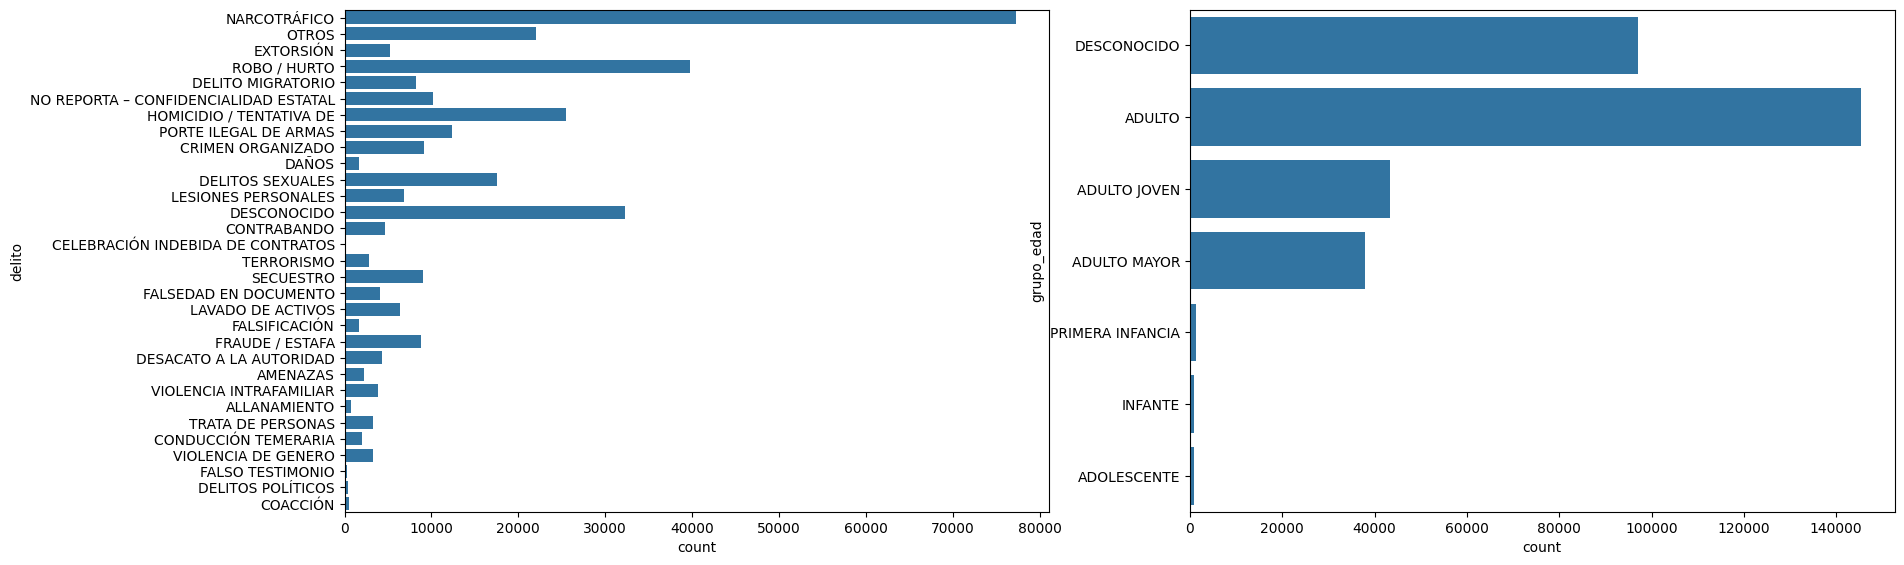

In [311]:
plt.figure(figsize=(20, 30))
plt.subplot(4, 2, 1)
sns.countplot(df_llenado_v1['delito'])
plt.subplot(4, 2, 2)
sns.countplot(df_llenado_v1['grupo_edad'])

## G. Reducción de valores delito

Se plantea realizar el siguiente mapeo de delitos a unas etiquetas que den una asociación lógica a los delitos allí incluídos:

In [312]:
mapeos_delitos = {
  'VIOLENCIA FÍSICA Y DE GÉNERO': [
    'HOMICIDIO / TENTATIVA DE',
    'LESIONES PERSONALES',
    'VIOLENCIA INTRAFAMILIAR',
    'VIOLENCIA DE GENERO',
    'AMENAZAS',
    'DELITOS SEXUALES'
  ],
  'DELITOS DE NARCOTRÁFICO Y CRIMEN ORGANIZADO': [
    'NARCOTRÁFICO',
    'CRIMEN ORGANIZADO',
    'LAVADO DE ACTIVOS',
    'CONTRABANDO',
    'EXTORSIÓN',
    'TRATA DE PERSONAS'
  ],
  'DELITOS CONTRA EL PATRIMONIO': [
    'ROBO / HURTO',
    'FRAUDE / ESTAFA',
    'DAÑOS',
    'ALLANAMIENTO',
    'SECUESTRO'
  ],
  'DELITOS CONTRA LA ADMINISTRACIÓN PÚBLICA': [
    'FALSEDAD EN DOCUMENTO',
    'FALSIFICACIÓN',
    'TERRORISMO',
    'DELITOS POLÍTICOS',
    'DESACATO A LA AUTORIDAD',
    'CELEBRACIÓN INDEBIDA DE CONTRATOS',
    'FALSO TESTIMONIO'
  ],
  'OTROS': [
    'PORTE ILEGAL DE ARMAS',
    'CONDUCCIÓN TEMERARIA',
    'DELITO MIGRATORIO',
    'OTROS',
    'NO REPORTA – CONFIDENCIALIDAD ESTATAL',
    'COACCIÓN'
  ]
}

Ahora, a realizar el mapeo (netamente semántico):

In [313]:
objeto_mapeo = {}
for key in mapeos_delitos:
  for delito in mapeos_delitos[key]:
    objeto_mapeo[delito] = key

df_mapeado = df_llenado_v1.copy()
df_mapeado['delito'] = df_mapeado['delito'].replace(objeto_mapeo)

Obteniendo así:

<Axes: xlabel='count', ylabel='delito'>

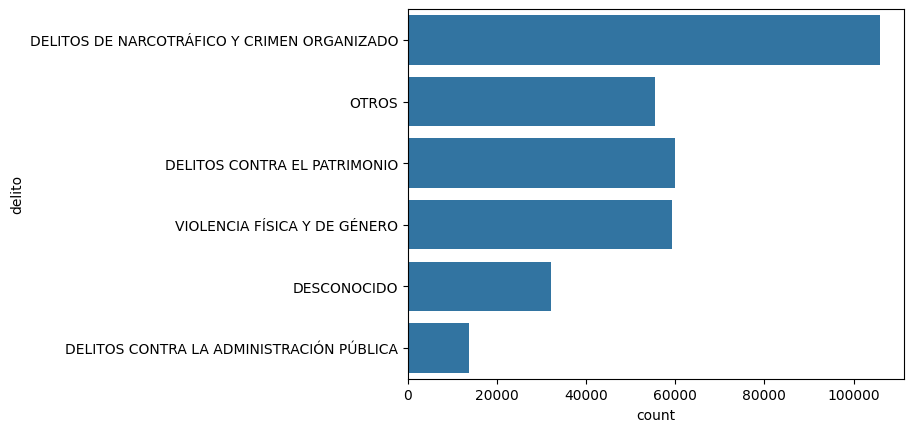

In [314]:
sns.countplot(df_mapeado['delito'])

Una vez reducidos los valores del atributo delito, se observa cómo ahora existen categorías con mayor peso y que presentan una signficancia semántica importante.

> El desconocido se tratará en la segunda parte del llenado de datos faltantes

## H. Tratamiento de valores faltantes (Parte 2)

### Valores faltantes atributo delito

<ipython-input-315-dd35231150c0>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_desconocido, x='grupo_edad',
<ipython-input-315-dd35231150c0>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_desconocido, x='g_nero',
<ipython-input-315-dd35231150c0>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_desconocido[df_desconocido['consulado'].isin(top_consulados)],


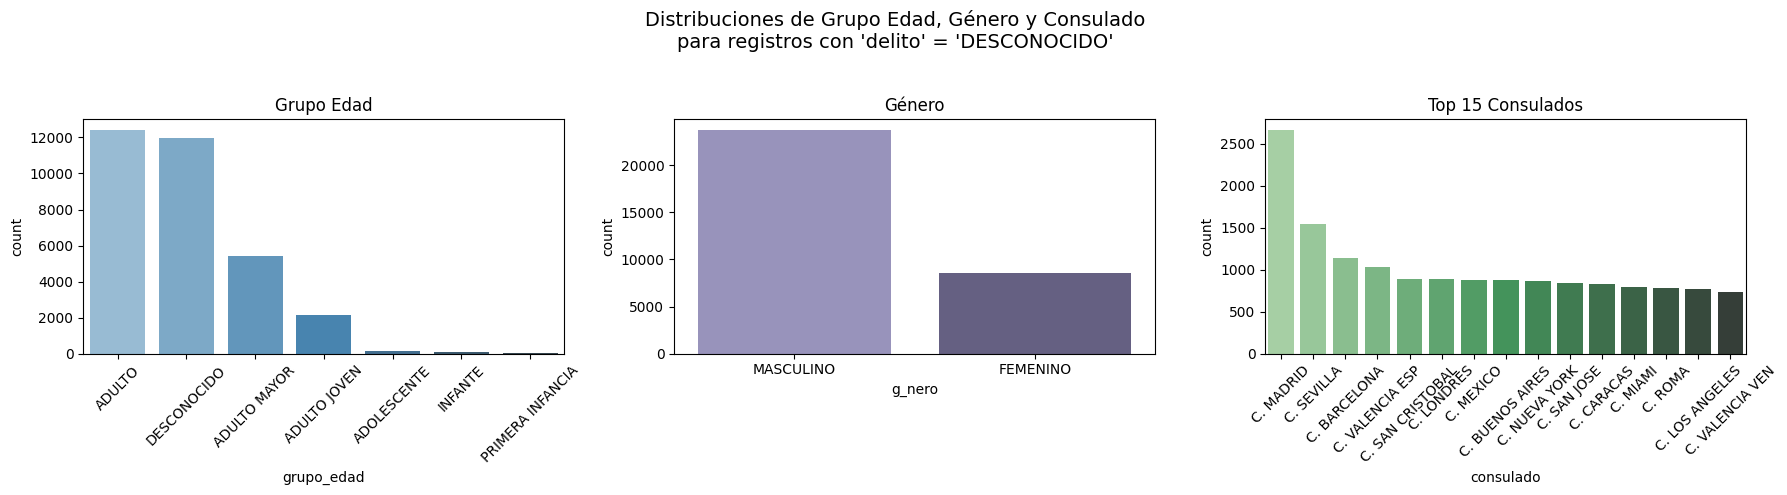

In [315]:
df_desconocido = df_mapeado[df_mapeado['delito'] == 'DESCONOCIDO']

# Crear figura y subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: grupo_edad
sns.countplot(data=df_desconocido, x='grupo_edad',
              order=df_desconocido['grupo_edad'].value_counts().index,
              ax=axes[0], palette='Blues_d')
axes[0].set_title("Grupo Edad")
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2: g_nero
sns.countplot(data=df_desconocido, x='g_nero',
              order=df_desconocido['g_nero'].value_counts().index,
              ax=axes[1], palette='Purples_d')
axes[1].set_title("Género")

# Subplot 3: consulado (solo top 10)
top_consulados = df_desconocido['consulado'].value_counts().nlargest(15).index
sns.countplot(data=df_desconocido[df_desconocido['consulado'].isin(top_consulados)],
              x='consulado', order=top_consulados,
              ax=axes[2], palette='Greens_d')
axes[2].set_title("Top 15 Consulados")
axes[2].tick_params(axis='x', rotation=45)

# Ajustar diseño
plt.suptitle("Distribuciones de Grupo Edad, Género y Consulado\npara registros con 'delito' = 'DESCONOCIDO'", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Como se puede observar, existe un patrón en los datos desconocidos del atributo delito: los consulados con más delitos reportados como desconocidos pertenecen a españa, viendo así que mantener este valor desconocido como una categoría puede aportar información adicional para los modelos a utilizar.

### Valores faltantes atributo grupo edad

Como se puede evidenciar en el la distribución de grupo edad dentro de los datos de delitos desconocidos, la proporción de valores desconocidos de grupo edad es bastante mayor a comparación de la distribución en el dataset global, indicando que puede que estos datos desconocidos sí aporten información al dejarse como una categoría más.

<ipython-input-317-107a08b05311>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_desconocido_edad, x='g_nero',
<ipython-input-317-107a08b05311>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_desconocido_edad[df_desconocido_edad['consulado'].isin(top15_consulados)],
<ipython-input-317-107a08b05311>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_desconocido_edad, y='delito',


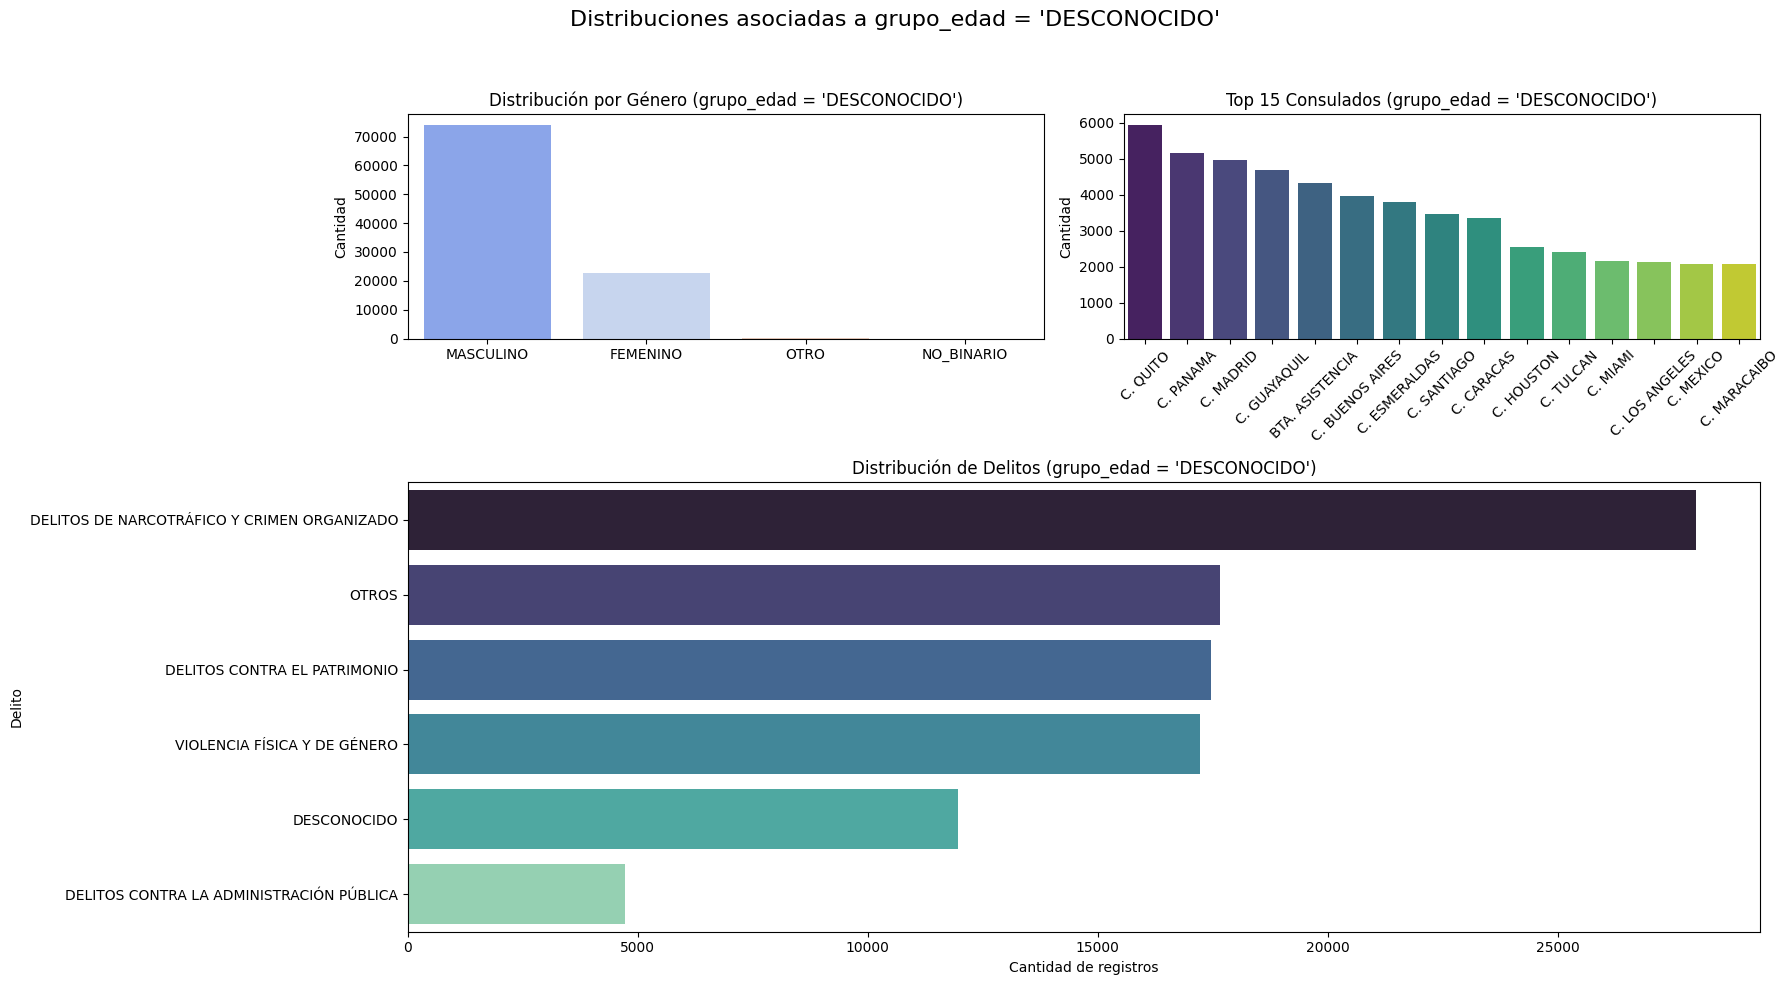

In [317]:
# Filtrar registros donde grupo_edad == 'DESCONOCIDO'
df_desconocido_edad = df_mapeado[df_mapeado['grupo_edad'] == 'DESCONOCIDO']

# Crear figura y layout 2x2, con fila 2 expandida para el gráfico horizontal
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2])  # segunda fila más alta

# Subplot 1: g_nero
ax1 = fig.add_subplot(gs[0, 0])
sns.countplot(data=df_desconocido_edad, x='g_nero',
              order=df_desconocido_edad['g_nero'].value_counts().index,
              ax=ax1, palette='coolwarm')
ax1.set_title("Distribución por Género (grupo_edad = 'DESCONOCIDO')")
ax1.set_xlabel("")
ax1.set_ylabel("Cantidad")

# Subplot 2: Top 15 Consulados
top15_consulados = df_desconocido_edad['consulado'].value_counts().nlargest(15).index
ax2 = fig.add_subplot(gs[0, 1])
sns.countplot(data=df_desconocido_edad[df_desconocido_edad['consulado'].isin(top15_consulados)],
              x='consulado', order=top15_consulados,
              ax=ax2, palette='viridis')
ax2.set_title("Top 15 Consulados (grupo_edad = 'DESCONOCIDO')")
ax2.tick_params(axis='x', rotation=45)
ax2.set_xlabel("")
ax2.set_ylabel("Cantidad")

# Subplot 3: Delito (horizontal), usando los valores como etiquetas del eje y
ax3 = fig.add_subplot(gs[1, :])
delito_order = df_desconocido_edad['delito'].value_counts().index
sns.countplot(data=df_desconocido_edad, y='delito',
              order=delito_order, ax=ax3, palette='mako')
ax3.set_title("Distribución de Delitos (grupo_edad = 'DESCONOCIDO')")
ax3.set_xlabel("Cantidad de registros")
ax3.set_ylabel("Delito")

# Ajustes generales
plt.suptitle("Distribuciones asociadas a grupo_edad = 'DESCONOCIDO'", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

En este caso, se observa que la distribución de consulados y de delitos varía, con respecto a sus distribuciones globales, teniendo así que dejar el valor 'DESCONOCIDO' como una categoría de grupo_edad más puede aportar información adicional a modelos de asociación y posiblemente predicción (dependiendo del modelo).

## I. Detección de outliers

El único atributo para el cual tiene sentido realizar un análisis de outliers es el de cantidad; el cual representa la cantidad de detenidos por un mismo delito que reporta un consulado en cada "período de compilado". Teniendo el siguiente boxplot:

<Axes: ylabel='cantidad'>

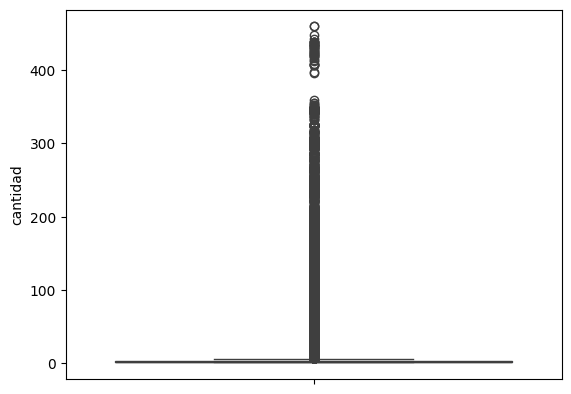

In [319]:
# Visualización y de outliers
sns.boxplot(df_mapeado["cantidad"])

Como se puede observar, el gráfico presenta una gran cantidad de outliers, por lo cual el simplemente reemplazarlos o eliminarlos para seguir tratando este atributo como numérico haría que se perdiese información valiosa. Haciendo una pequeña revisión podemos ver los valores de este atributo que están presentes en más de 20000 registros (aproximadamente un 94%)

In [320]:
counts = df_mapeado['cantidad'].value_counts()
counts[counts > 20000]

,count
cantidad,
1,181817
2,50305
3,22524


En base a esto es evidente el por qué el boxplot se ve de esta manera, pero queda la duda de cuántos diferentes valores quedan en el restante de los datos y en cuántos registros están presentes

In [321]:
print(f'Valores diferentes: {len(counts[counts <= 20000].index.tolist())}')
print(f'Cantidad de registros: {counts[counts <= 20000].sum()}')
print(f'Porcentaje de registros: {counts[counts <= 20000].sum()*100/len(df)}%')

Valores diferentes: 360
Cantidad de registros: 71922
Porcentaje de registros: 19.97833333333333%


Teniendo así que hay otros 360 valores distintos que puede tomar esta variable, y que estos están presentes en más de 79mil registros. Representando así cerca de un 20% de los datos, por lo cual se evidencia la importancia de mantenerlos. Por esto, se propone discretizar este atributo y que sea categórico, para darle un mayor peso a estos registros y que exista la posibilidad de encontrar relaciones valiosas en base a estos.

In [323]:
min_count = counts[counts <= 20000].min()
valores_min = counts[counts == min_count].index.tolist()
print(f'Cantidad con conteo mínimo en rango de 20mil: {valores_min}')
print(f'Cantidad con conteo máximo en rango de 20mil: {counts[counts <= 20000].idxmax()}')

Cantidad con conteo mínimo en rango de 20mil: [352, 351, 359, 443, 396, 398, 353, 448, 326, 225, 344, 288, 433, 216, 219, 261, 224, 317, 423, 275, 427, 429, 310, 424, 217, 417, 414, 419, 425, 421, 251, 412, 273, 323, 337, 260, 336, 269, 335, 334]
Cantidad con conteo máximo en rango de 20mil: 4


Como se puede observar, los valores de estos conteos van desde 4 hasta valores superiores a 400. Por lo cual se proponen los siguientes grupos:

  - Grupo de 1 detenido
  - Grupo de 2 a 5 detenidos
  - Grupo de 6 a 10 detenidos
  - Grupo de 11 a 20 detenidos
  - Grupo de más 20 detenidos

Para así obtener una variedad que aporte información y al mismo tiempo le dé más peso a valores extremos, viendo a continuación la cantidad y porcentaje de registros de cada grupo:

In [325]:
long_1 = len(df_mapeado[df_mapeado['cantidad'] == 1])
long_2_a_5 = len(df_mapeado[np.logical_and(df_mapeado['cantidad'] > 1, df_mapeado['cantidad'] <= 5)])
long_6_a_10 = len(df_mapeado[np.logical_and(df_mapeado['cantidad'] > 5, df_mapeado['cantidad'] <= 10)])
long_11_a_20 = len(df_mapeado[np.logical_and(df_mapeado['cantidad'] > 10, df_mapeado['cantidad'] <= 20)])
long_mas_20 = len(df_mapeado[df_mapeado['cantidad'] > 20])

long_dataset = len(df_mapeado)

print(f'Registros en grupo 1 detenido: {long_1}')
print(f'Porcentaje de registros en grupo 1 detenido: {long_1*100/long_dataset}%\n')
print(f'Registros en grupo de 2 a 5 detenidos: {long_2_a_5}')
print(f'Porcentaje de registros en grupo de 2 a 5 detenidos: {long_2_a_5*100/long_dataset}%\n')
print(f'Registros en grupo de 6 a 10 detenidos: {long_6_a_10}')
print(f'Porcentaje de registros en grupo de 6 a 10 detenidos: {long_6_a_10*100/long_dataset}%\n')
print(f'Registros en grupo de 11 a 20 detenidos: {long_11_a_20}')
print(f'Porcentaje de registros en grupo de 11 a 20 detenidos: {long_11_a_20*100/long_dataset}%\n')
print(f'Registros en grupo de más de 20 detenidos: {long_mas_20}')
print(f'Porcentaje de registros en grupo de más de 20 detenidos: {long_mas_20*100/long_dataset}%')

Registros en grupo 1 detenido: 181817
Porcentaje de registros en grupo 1 detenido: 55.67508145317361%

Registros en grupo de 2 a 5 detenidos: 97416
Porcentaje de registros en grupo de 2 a 5 detenidos: 29.830234438156833%

Registros en grupo de 6 a 10 detenidos: 21946
Porcentaje de registros en grupo de 6 a 10 detenidos: 6.720193037897161%

Registros en grupo de 11 a 20 detenidos: 12934
Porcentaje de registros en grupo de 11 a 20 detenidos: 3.9605840131304966%

Registros en grupo de más de 20 detenidos: 12455
Porcentaje de registros en grupo de más de 20 detenidos: 3.8139070576419%


Se encuentra esta distribución aceptable, por lo que se procede a hacer el reemplazo en el dataset

In [326]:
df_final = df_mapeado.copy()
df_final['cantidad_detenidos'] = df['cantidad'].apply(
  lambda x: (
      '1' if x == 1 else
      '2 a 5' if 2 <= x <= 5 else
      '6 a 10' if 6 <= x <= 10 else
      '11 a 20' if 11 <= x <= 20 else
      'más de 20'
  )
)
df_final.drop(columns=['cantidad'], inplace=True)

Teniendo así:

<Axes: xlabel='count', ylabel='cantidad_detenidos'>

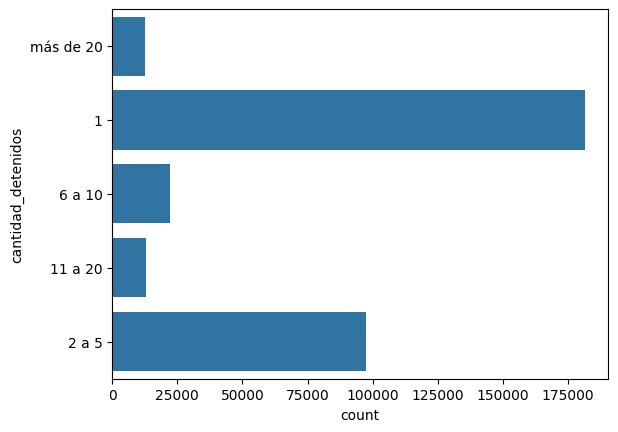

In [328]:
sns.countplot(df_final['cantidad_detenidos'])

#  Guardado de los datos


Para finalizar, se guardan los datos pre-procesados en un csv y se descargan

In [334]:
from google.colab import files
# Si se va a utilizar en entornos diferentes a excel, usar utf-8:
df_final.to_csv("colombianos_detenidos_preprocesado.csv", index=False, encoding='utf-8')
# Si se va a utilizar en excel, usar utf-8-sig
df_final.to_csv("colombianos_detenidos_preprocesado_excel.csv", index=False, encoding='utf-8-sig')
# Comentar basado en el archivo que se quiere
files.download('colombianos_detenidos_preprocesado.csv')
# files.download('colombianos_detenidos_preprocesado_excel.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>